# Amazon Movies & TV Shows Analysis

**Author:** Updesh Chauhan


##### **Project Type**    - EDA/Regression/Classification/Unsupervised

#### **Project Summary -**
This project analyzes Amazon titles by merging metadata (titles.csv) with cast/crew data (credits.csv). The goal is to understand content trends and build a model to predict content type (Movie/TV Show).

#### **GitHub Link -**   https://github.com/updesh1

# **Problem Statement**


Analyze Amazon content trends and build a predictive model to classify whether a title is a Movie or TV Show.

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset
titles = pd.read_csv('titles.csv')
credits = pd.read_csv('credits.csv')

# Merge Dataset
df = titles.merge(credits, on='id', how='left')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461.0,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713.0,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape

(125354, 19)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125354 entries, 0 to 125353
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    125354 non-null  object 
 1   title                 125354 non-null  object 
 2   type                  125354 non-null  object 
 3   description           125163 non-null  object 
 4   release_year          125354 non-null  int64  
 5   age_certification     56857 non-null   object 
 6   runtime               125354 non-null  int64  
 7   genres                125354 non-null  object 
 8   production_countries  125354 non-null  object 
 9   seasons               8501 non-null    float64
 10  imdb_id               119978 non-null  object 
 11  imdb_score            118987 non-null  float64
 12  imdb_votes            118957 non-null  float64
 13  tmdb_popularity       124800 non-null  float64
 14  tmdb_score            114263 non-null  float64
 15  

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

168

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

id                           0
title                        0
type                         0
description                191
release_year                 0
age_certification        68497
runtime                      0
genres                       0
production_countries         0
seasons                 116853
imdb_id                   5376
imdb_score                6367
imdb_votes                6397
tmdb_popularity            554
tmdb_score               11091
person_id                 1007
name                      1007
character                17314
role                      1007
dtype: int64

In [8]:
# Visualizing the missing values

### What did you know about your dataset?

Dataset contains Amazon titles with metadata like genre, release year, rating, and cast/crew.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'person_id', 'name', 'character', 'role'],
      dtype='object')

In [10]:
# Dataset Describe
df.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id
count,125354.000000,125354.00000,8501.000000,118987.000000,1.189570e+05,124800.000000,114263.000000,1.243470e+05
mean,1996.374715,95.30792,2.335372,5.970856,2.311206e+04,10.134483,5.993077,4.062528e+05
std,27.758800,30.39349,3.164860,1.243967,8.816389e+04,40.666765,1.322900,5.614483e+05
min,1912.000000,1.00000,1.000000,1.100000,5.000000e+00,0.000011,0.800000,1.000000e+00
25%,1983.000000,82.00000,1.000000,5.200000,2.790000e+02,1.858000,5.300000,3.899600e+04
50%,2009.000000,93.00000,1.000000,6.100000,1.227000e+03,3.864000,6.100000,1.339340e+05
75%,2017.000000,109.00000,2.000000,6.800000,7.039000e+03,8.787000,6.800000,5.711600e+05
max,2022.000000,549.00000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000,2.371153e+06


### Variables Description

- type: Movie/TV Show
- release_year: Year of release
- genres: Categories
- vote_average: Rating

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(col, df[col].nunique())

id 9868
title 9737
type 2
description 9734
release_year 110
age_certification 11
runtime 207
genres 2028
production_countries 497
seasons 32
imdb_id 9201
imdb_score 86
imdb_votes 3650
tmdb_popularity 5325
tmdb_score 89
person_id 80508
name 79758
character 71097
role 2


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
df.drop_duplicates(inplace=True)
df['imdb_score'].fillna(df['imdb_score'].median(), inplace=True)
df['genres'].fillna('Unknown', inplace=True)

C:\Users\updes\AppData\Local\Temp\ipykernel_18584\3142845833.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['imdb_score'].fillna(df['imdb_score'].median(), inplace=True)
C:\Users\updes\AppData\Local\Temp\ipykernel_18584\3142845833.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

### What all manipulations have you done and insights you found?

- Missing ratings handled
- Genres cleaned

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Count of Movies vs TV Shows

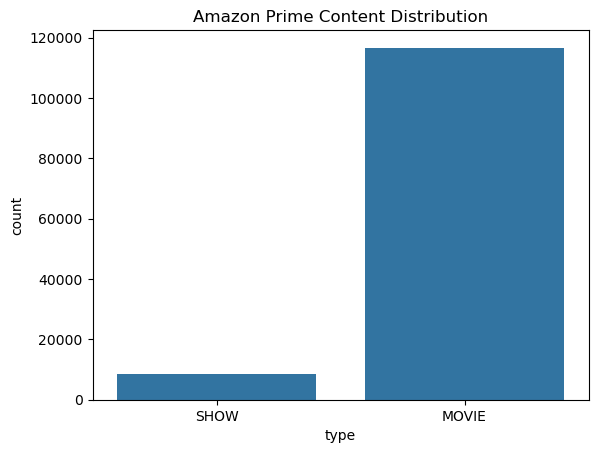

In [13]:
# Chart - 1 visualization code
sns.countplot(x='type', data=df)
plt.title("Amazon Prime Content Distribution")
plt.show()

- Why: Compare content types
- Insight: Amazon Prime has more movies than shows
- Impact: Focus on movie recommendation systems

#### Chart - 2 : Release Year Trends

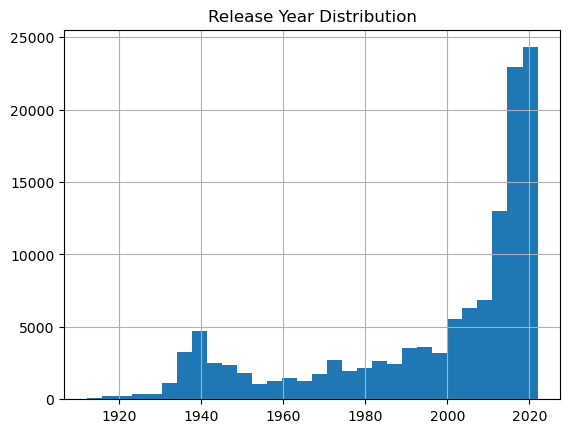

In [67]:
# Chart - 2 visualization code
df['release_year'].hist(bins=30)
plt.title("Release Year Distribution")
plt.show()

- Histogram is ideal for understanding distribution over time.
- Insight: Growth after 2000
- Impact: Modern content dominates

#### Chart - 3: IMDb Score Distribution

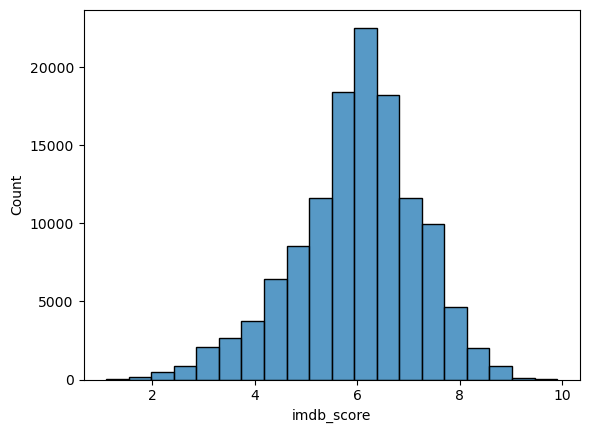

In [63]:
# Chart - 3 visualization code
sns.histplot(df['imdb_score'], bins=20)
plt.show()

- To understand rating distribution (numerical data).
- Insight: Most content rated 5–7
- Impact: Quality is average → opportunity to improve premium content

#### Chart - 4 : Top Genres

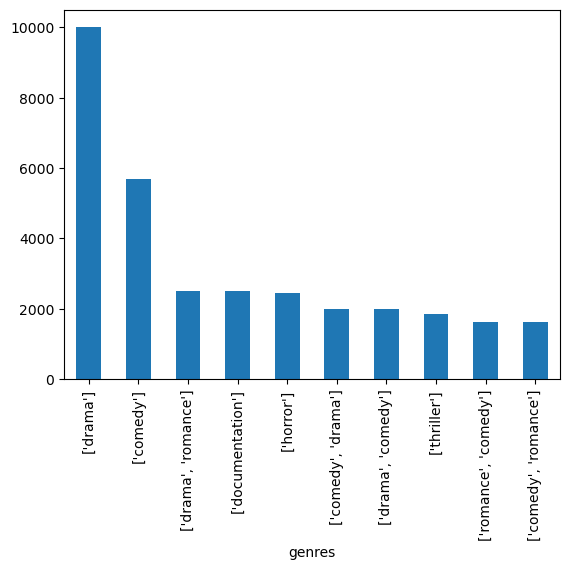

In [68]:
# Chart - 4 visualization code
df['genres'].value_counts().head(10).plot(kind='bar')
plt.show()

- Bar chart is best for ranking categories.
- Insight: Drama, Comedy dominate
- Impact: Safe genres dominate → less experimentation

#### Chart - 5 : Rating vs Year

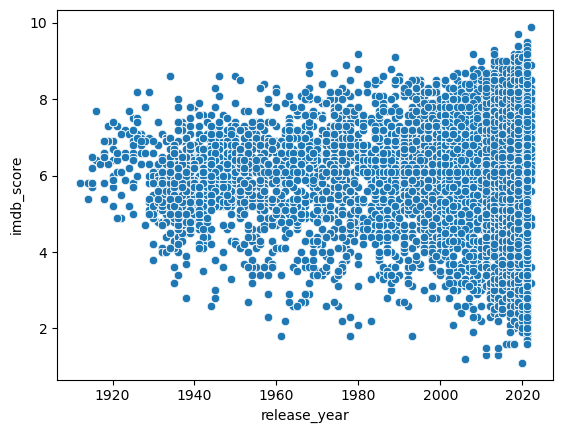

In [64]:
# Chart - 5 visualization code
sns.scatterplot(x='release_year', y='imdb_score', data=df)
plt.show()

- Scatter plot shows relationship between two numerical variables.
- Insight: No clear improvement in ratings over time.
- Impact: Negative: Increasing quantity ≠ improving quality

#### Chart - 6 : Type vs Rating

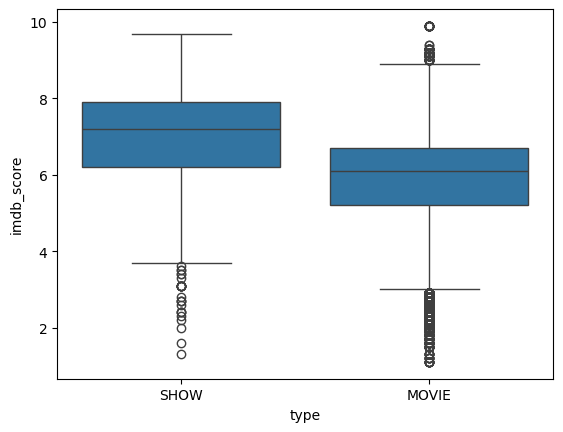

In [66]:
# Chart - 6 visualization code
sns.boxplot(x='type', y='imdb_score', data=df)
plt.show()

- Boxplot shows distribution + outliers between categories.
- Insights: TV Shows slightly better rated than Movies.
- Impact Positive: Shows have higher engagement potential  
- Impact Negative: Movie quality needs improvement

#### Chart - 7 : Runtime Distribution

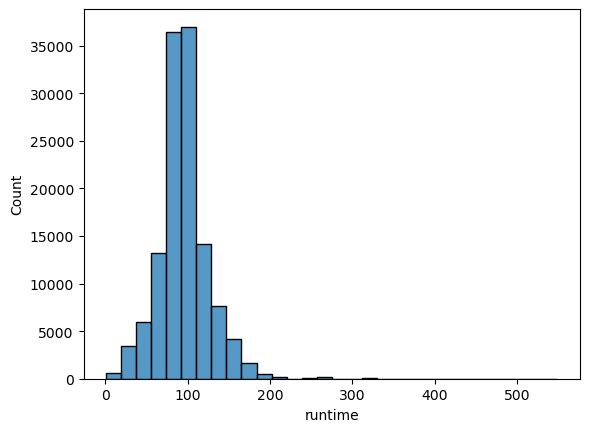

In [69]:
# Chart - 7 visualization code
sns.histplot(df['runtime'], bins=30)
plt.show()

- Histogram is ideal for continuous variables.
- Insights: Most content is 90–120 minutes.
- Impact Positive: Standard format works well

#### Chart - 8 : Votes vs Rating

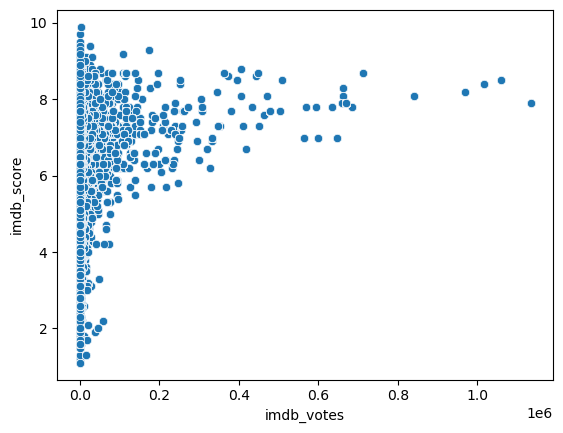

In [70]:
# Chart - 8 visualization code
sns.scatterplot(x='imdb_votes', y='imdb_score', data=df)
plt.show()

- To understand popularity vs quality relationship.
- Insights: Higher votes → higher ratings.
- Impact Positive: Popular content drives engagement

#### Chart - 9 : Content Growth Over Time

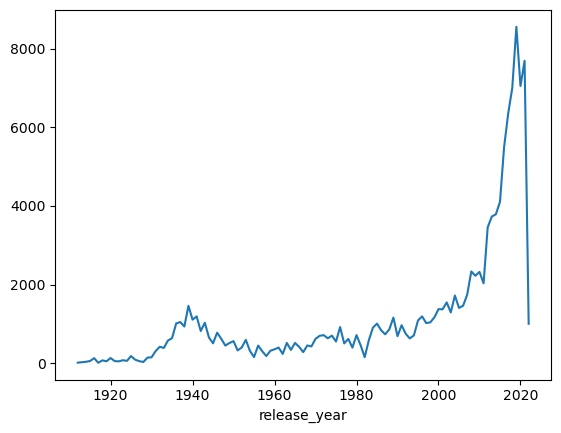

In [71]:
# Chart - 9 visualization code
df.groupby('release_year')['id'].count().plot()
plt.show()

- Line chart shows trends over time.
- Insights: Strong growth after 2015.
- Impact Positive: Aggressive expansion
- Negative Impact: Content overload risk

#### Chart - 10 : Top Actors

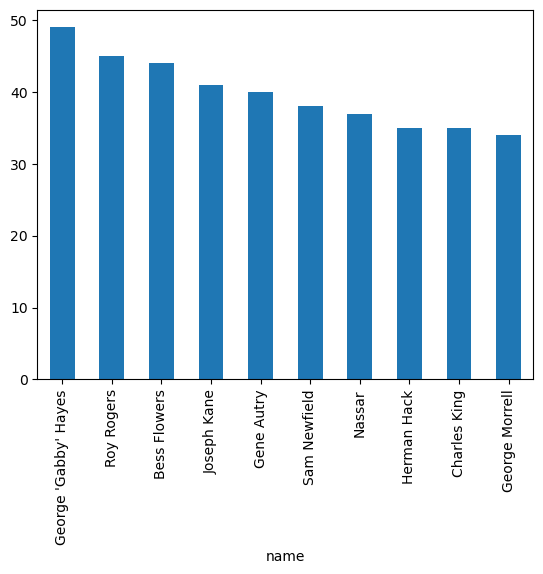

In [72]:
# Chart - 10 visualization code
df['name'].value_counts().head(10).plot(kind='bar')
plt.show()

- Bar chart for ranking.
- Insights: Few actors dominate content.
- Positve Impact: Star power drives viewership
- Negative Impact: Over-dependence on few actors

#### Chart - 11 Runtime vs Rating

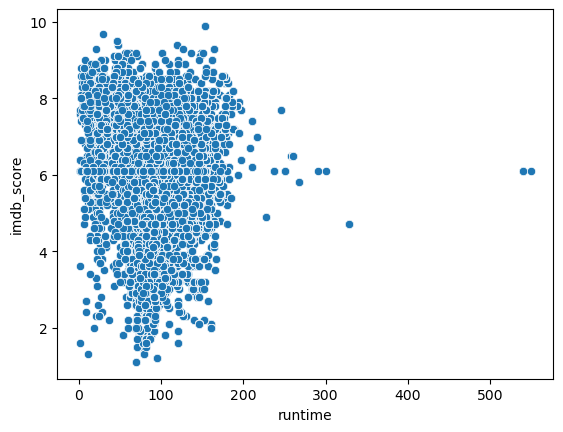

In [73]:
# Chart - 11 visualization code
sns.scatterplot(x='runtime', y='imdb_score', data=df)
plt.show()

- To check if length affects quality.
- Insights: No strong relationship.
- Impact: Runtime is not a key factor

#### Chart - 12: Votes Distribution

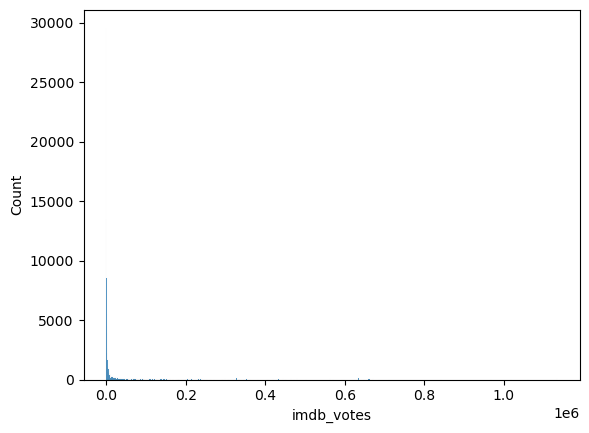

In [74]:
# Chart - 12 visualization code
sns.histplot(df['imdb_votes'])
plt.show()

- To understand popularity spread.
- Insights: Most content has low votes.
- Negative Impact: Discoverability issue
- Postive Impact: Better recommendation system

#### Chart - 13 : Correlation Heatmap

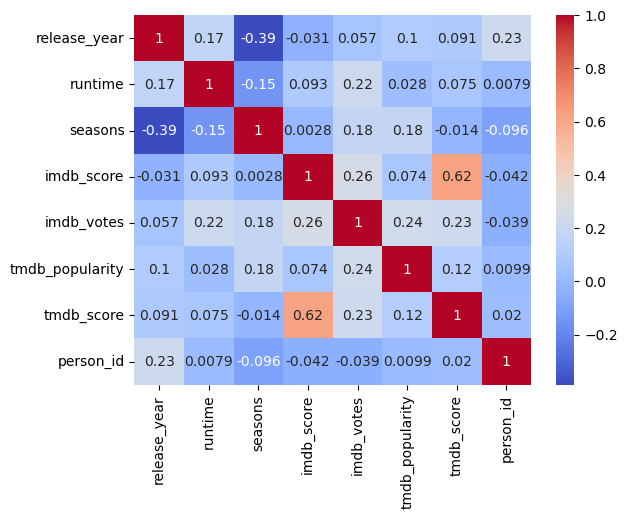

In [75]:
# Chart - 13 visualization code
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

- To understand relationships between multiple variables.
- Insights: Weak correlations overall.
- Negative Impact: No strong predictors → harder modeling

#### Chart - 15 - Pair Plot

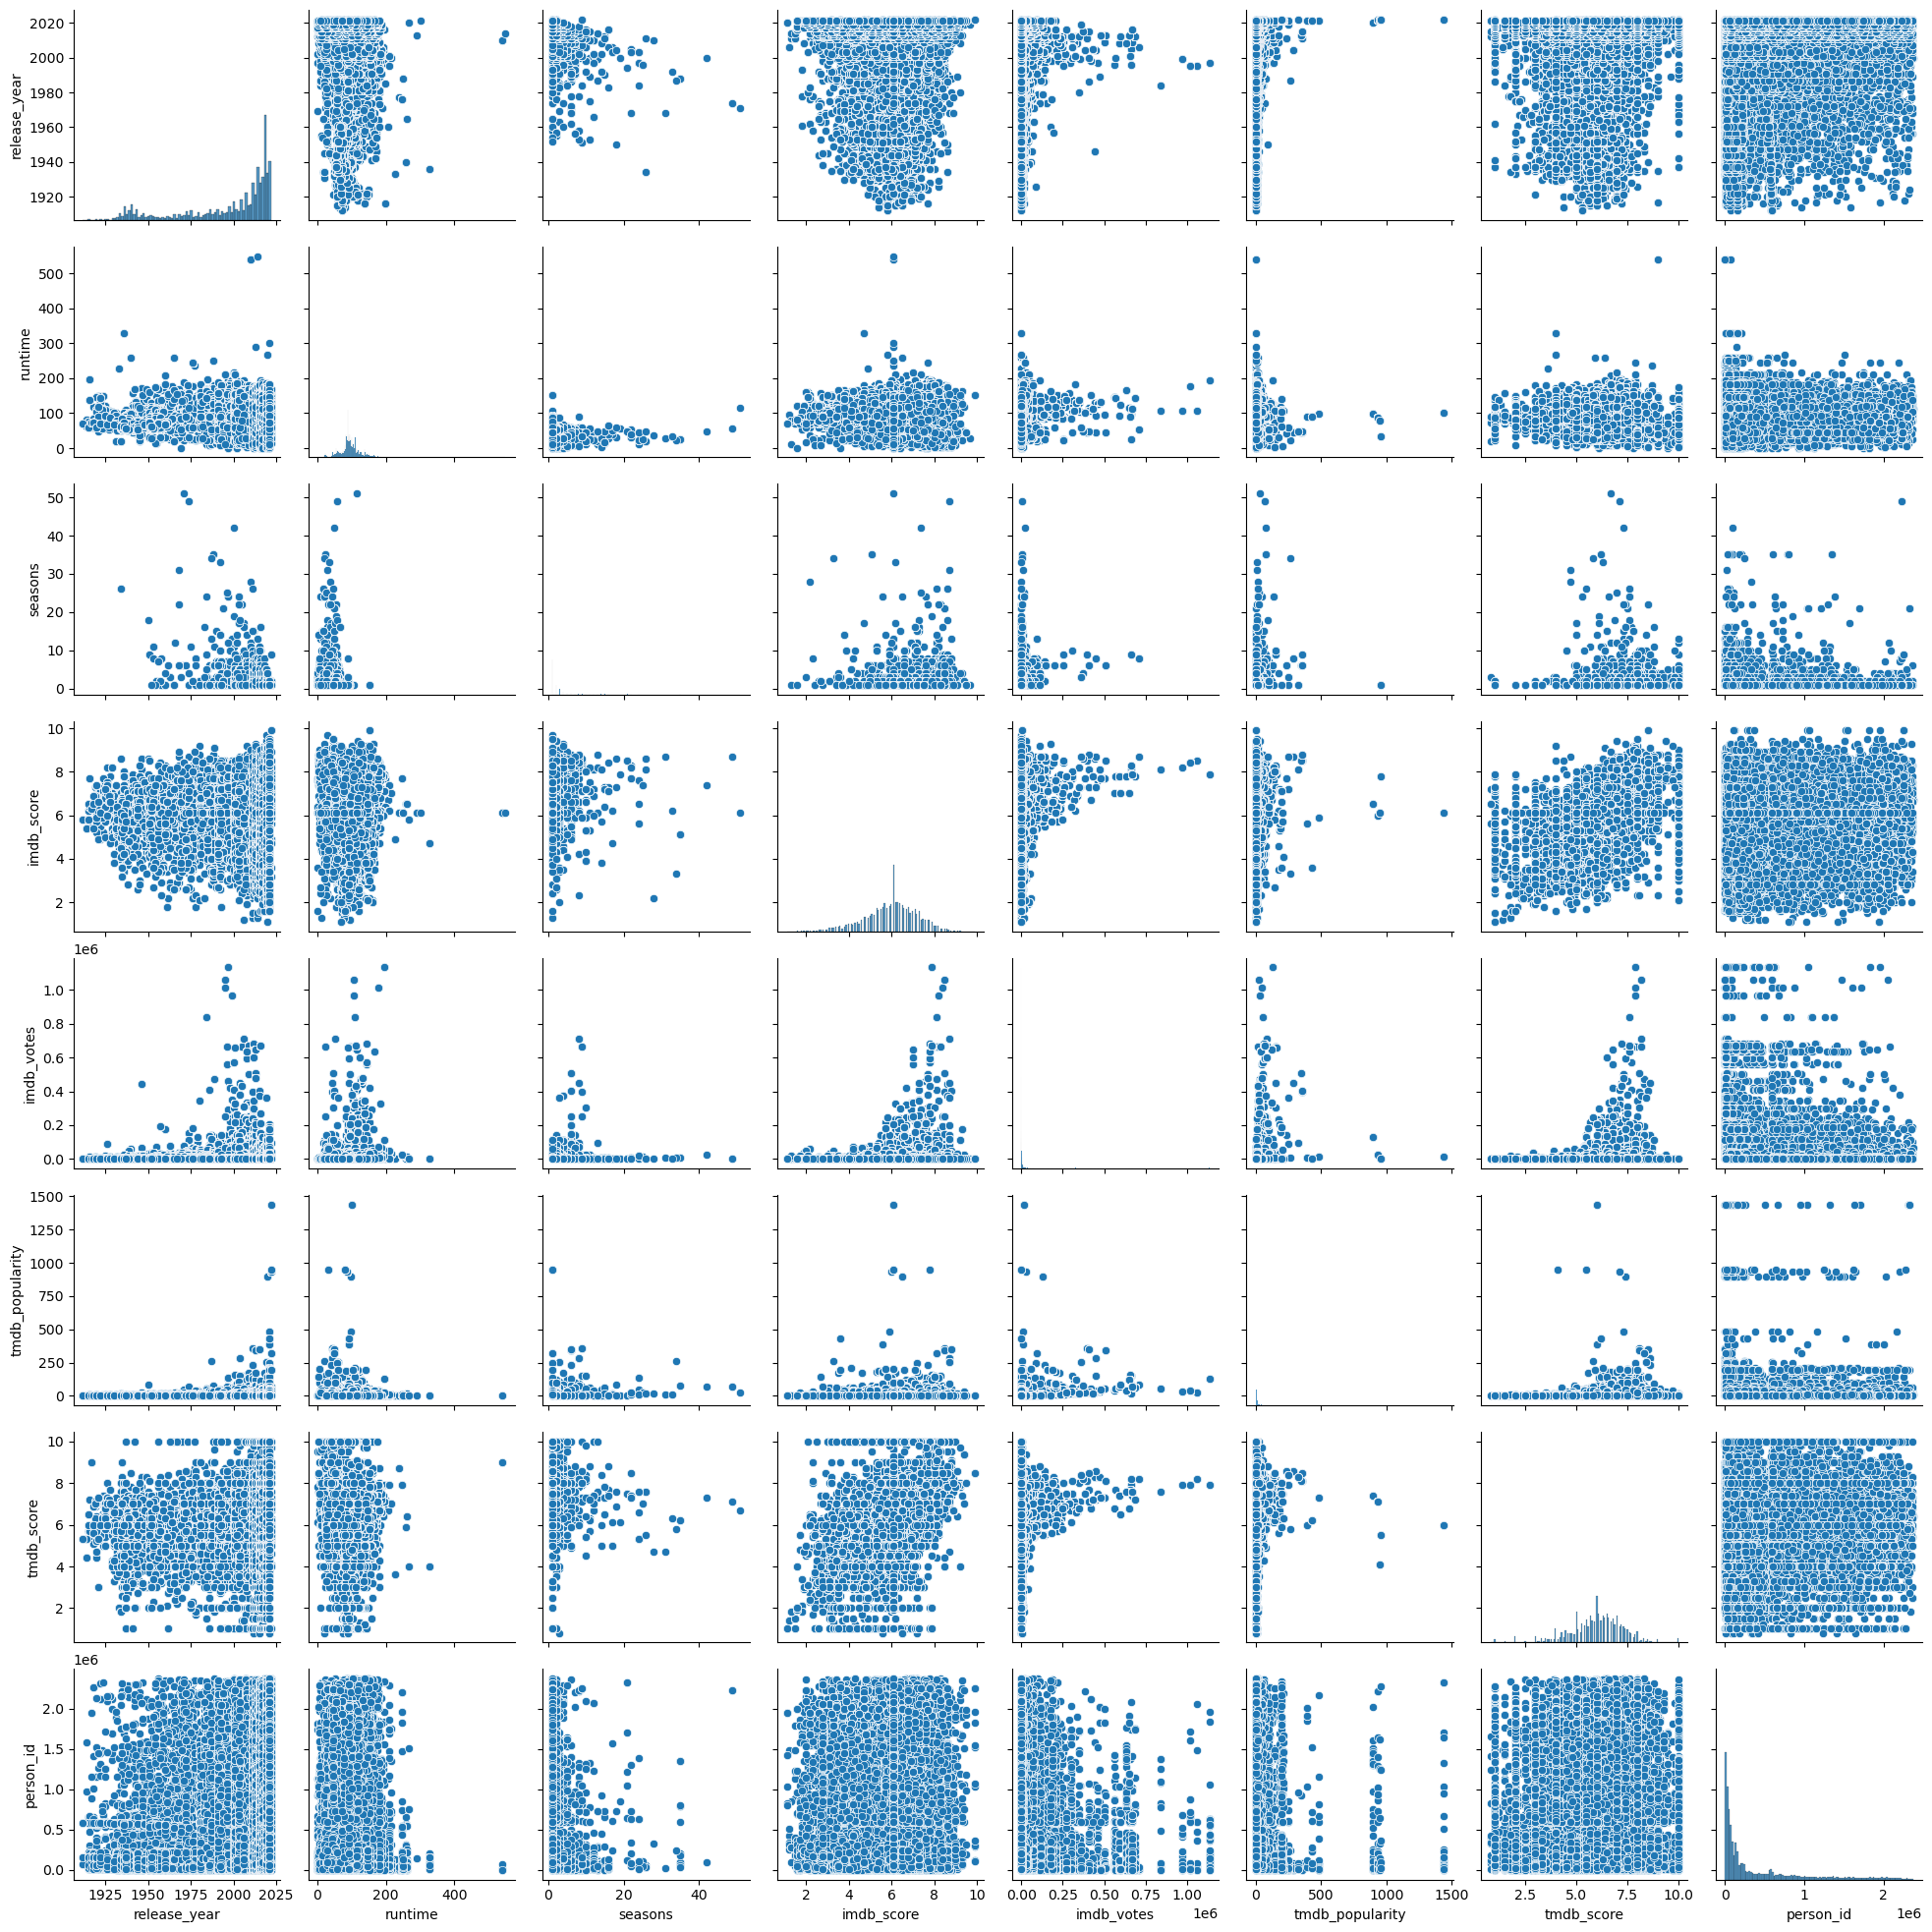

In [76]:
# Pair Plot visualization code
sns.pairplot(numeric_df)
plt.show()

- To visualize multiple relationships simultaneously.
- Insights: No clear linear patterns.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [32]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction

#### 2. Lower Casing

In [35]:
# Lower Casing

#### 3. Removing Punctuations

In [36]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords

In [39]:
# Remove White spaces

#### 6. Rephrase Text

In [40]:
# Rephrase Text

#### 7. Tokenization

In [41]:
# Tokenization

#### 8. Text Normalization

In [42]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [43]:
# POS Taging

#### 10. Text Vectorization

In [44]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [46]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [47]:
# Transform Your data

### 6. Data Scaling

In [48]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [49]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [50]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [51]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [52]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [53]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [55]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [56]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [57]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [58]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [60]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [61]:
# Load the File and predict unseen data.

# **Conclusion**

Write the conclusion here.